In [1]:
import jax.numpy as np
import jaxwt as jwt
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.datasets import face, ascent
import dorito
import cmasher as cmr

import jax

jax.config.update("jax_enable_x64", True)

2025-02-11 18:02:27.816024: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
wl = dorito.wavelets.Wavelets(ascent())

wl.distribution.sum() * 0.25837363

Array(0.25837363, dtype=float64)

In [3]:
wl = wl.multiply("approx", 2)
wl = wl.normalise()
wl.approx.sum() + wl.values.sum()

Array(0.25846238, dtype=float64)

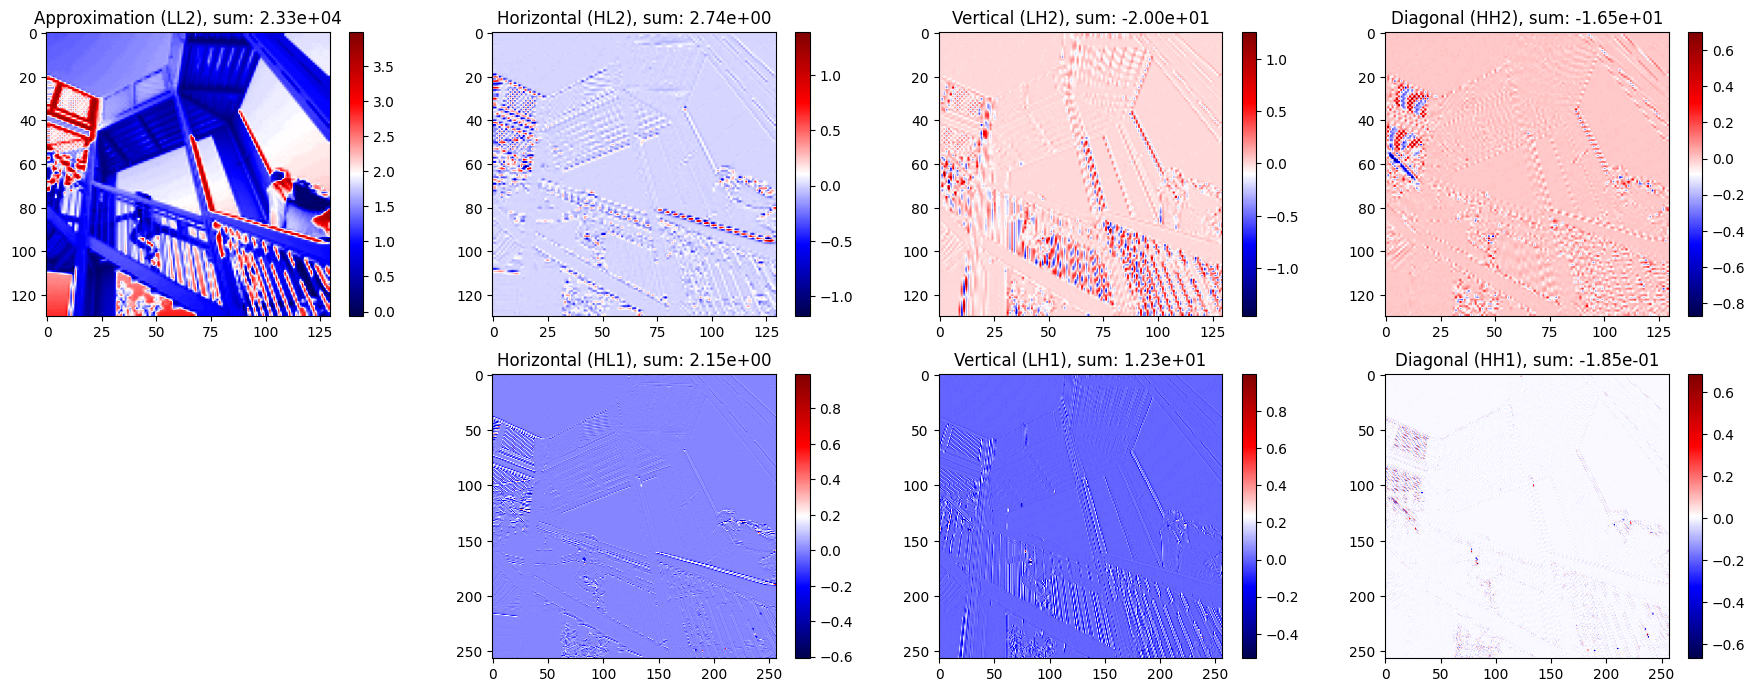

In [4]:
# Load and preprocess the image
# image = np.transpose(ascent(), [1, 0, 2])  # [..., 0]  # Convert to grayscale
image = ascent().astype(np.float32) / 255.0

# Perform 2-level wavelet decomposition using the Haar wavelet
coeffs = jwt.wavedec2(image, wavelet="db2", level=2)


def level2_plot(coeffs):
    # Extract the decomposition coefficients
    ll2, (hl2, lh2, hh2), (hl1, lh1, hh1) = coeffs

    # Plotting corner plot visualization
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    titles = [
        "Approximation (LL2)",
        "Horizontal (HL2)",
        "Vertical (LH2)",
        "Diagonal (HH2)",
        "Horizontal (HL1)",
        "Vertical (LH1)",
        "Diagonal (HH1)",
    ]

    coeff_plots = [ll2, hl2, lh2, hh2, hl1, lh1, hh1]
    positions = [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3)]

    # Plot each coefficient sub-band
    for (i, j), coeff, title in zip(positions, coeff_plots, titles):
        ax = axes[i, j]
        c = ax.imshow(coeff.squeeze(), cmap="seismic")
        ax.set_title(title + f", sum: {coeff.sum():.2e}")
        # ax.axis("off")
        fig.colorbar(
            c,
            ax=ax,
        )

    axes[1, 0].axis("off")  # Hide unused subplot
    plt.tight_layout()
    plt.show()


level2_plot(coeffs)

0.04772009788695771


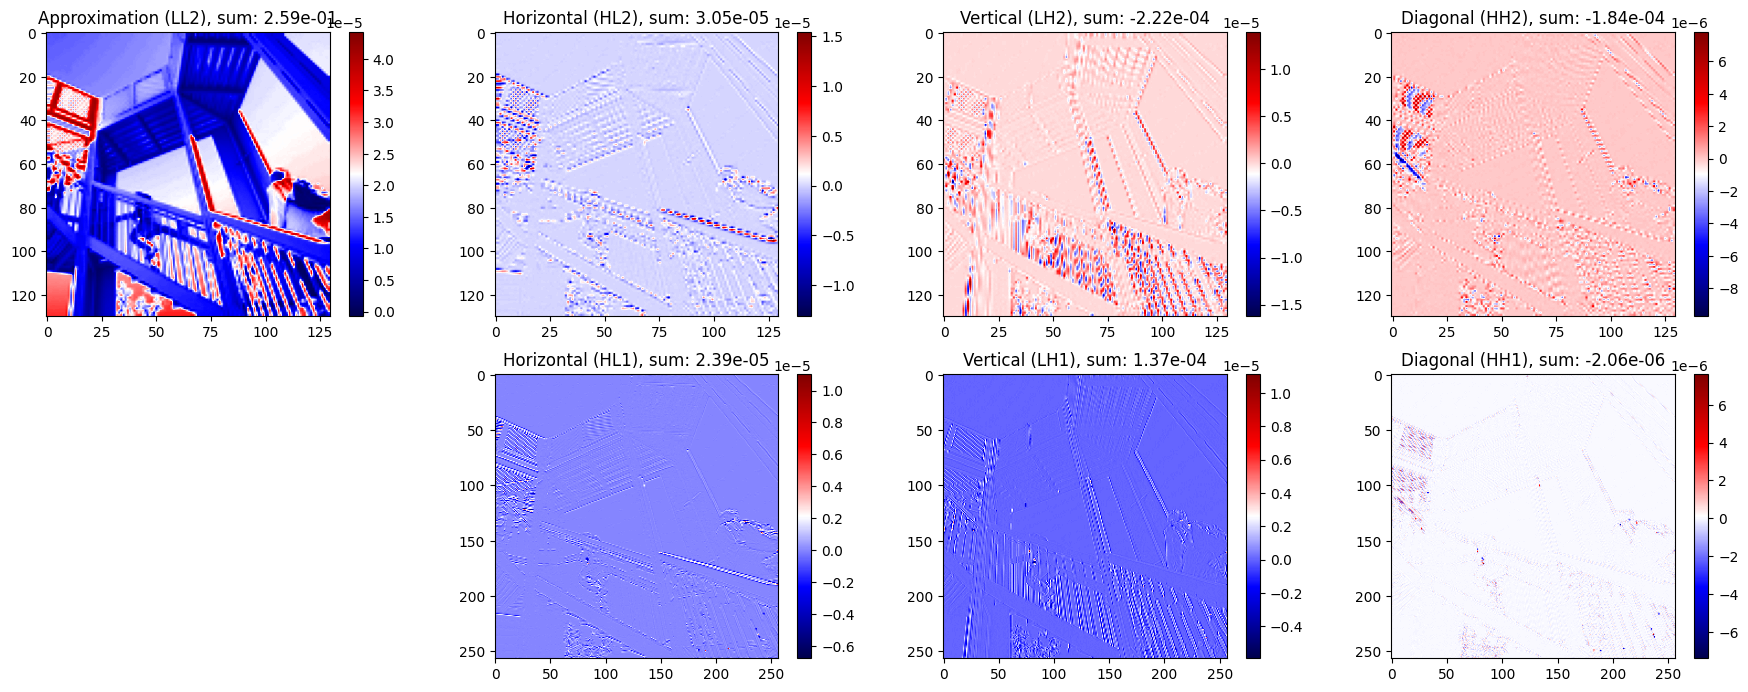

0.044538102542935075


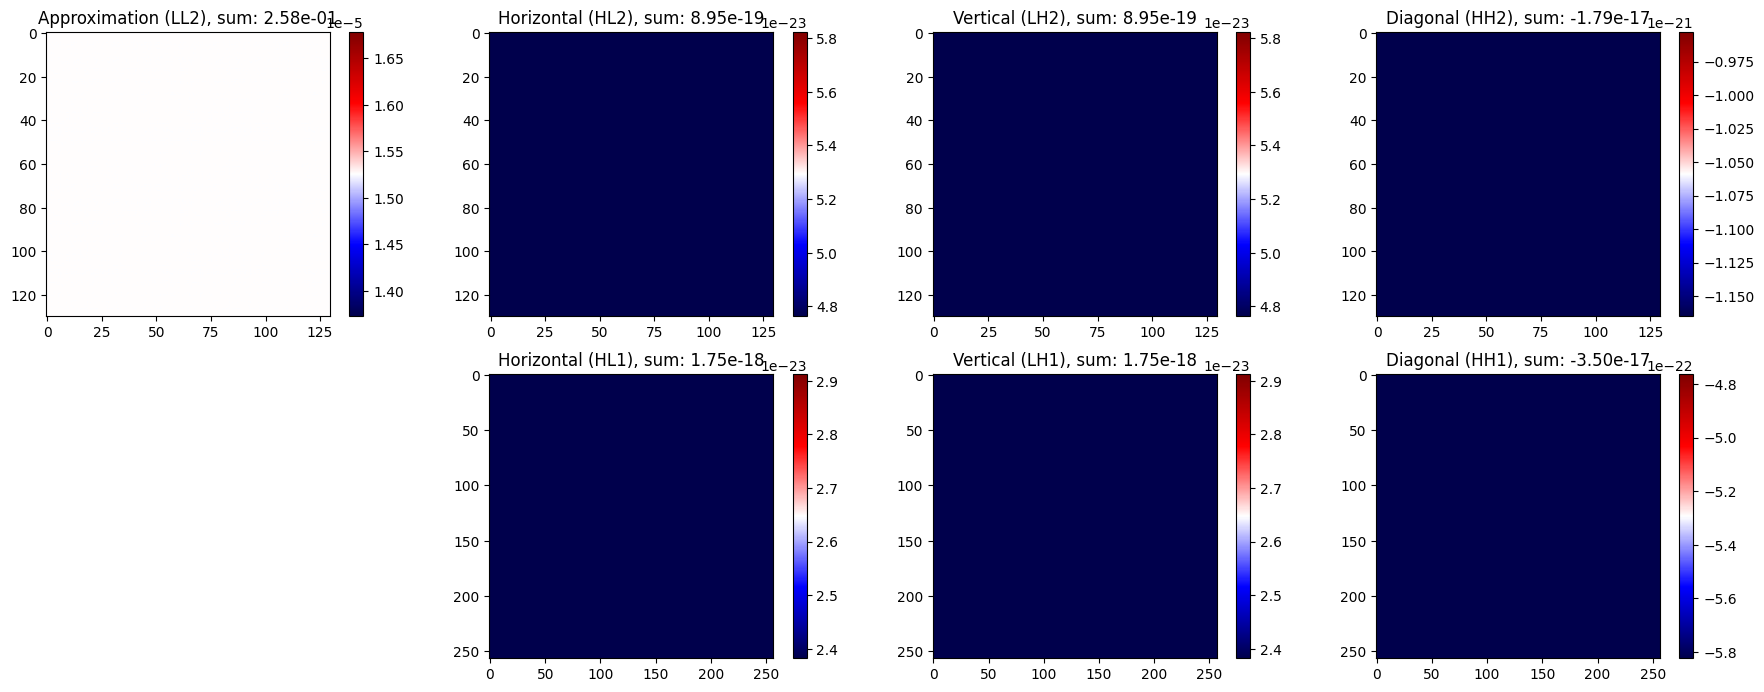

In [5]:
im = ascent() / ascent().sum()
wavelet = dorito.wavelets.Wavelets(im)

coeffs = np.hstack((wavelet.approx.flatten(), wavelet.values))
l2 = np.sqrt(np.linalg.norm(coeffs, ord=2))
print(l2)
level2_plot([wavelet.approx, *wavelet.build])


im2 = np.ones_like(im)
im2 /= im2.sum()
wavelet2 = dorito.wavelets.Wavelets(im2)

coeffs = np.hstack((wavelet2.approx.flatten(), wavelet2.values))
l2 = np.sqrt(np.linalg.norm(coeffs, ord=2))
print(l2)
level2_plot([wavelet2.approx, *wavelet2.build])

In [64]:
def tree_plot(coeffs, lvl):

    # approximation
    A = coeffs[0].squeeze()
    levels = [A]

    # details
    for level in coeffs[1:]:
        H = level[0].squeeze()
        V = level[1].squeeze()
        D = level[2].squeeze()

        levels += [H, V, D]

    # generating subplot axes kwargs
    axes = [
        (2**lvl, 2**lvl, 1),
        *[(2**j, 2**j, i) for j in range(lvl, 0, -1) for i in [2, 2**j + 1, 2**j + 2]],
    ]

    # plotting
    plt.figure(figsize=2 * [6 + (2**lvl)])

    # looping over subplots
    for i, ax_kwargs in enumerate(axes):

        arr = levels[i]

        # approximatino
        if i == 0:
            cmap = "viridis"
            vmin, vmax = None, None

        # details
        else:
            cmap = "cmr.wildfire"
            v = np.nanmax(np.abs(arr))
            vmin, vmax = -v, v

        imshow_kwargs = {"cmap": cmap, "vmin": vmin, "vmax": vmax}

        ax = plt.subplot(*ax_kwargs)
        ax.axis("off")
        ax.imshow(arr, **imshow_kwargs)

    plt.tight_layout()
    plt.show()

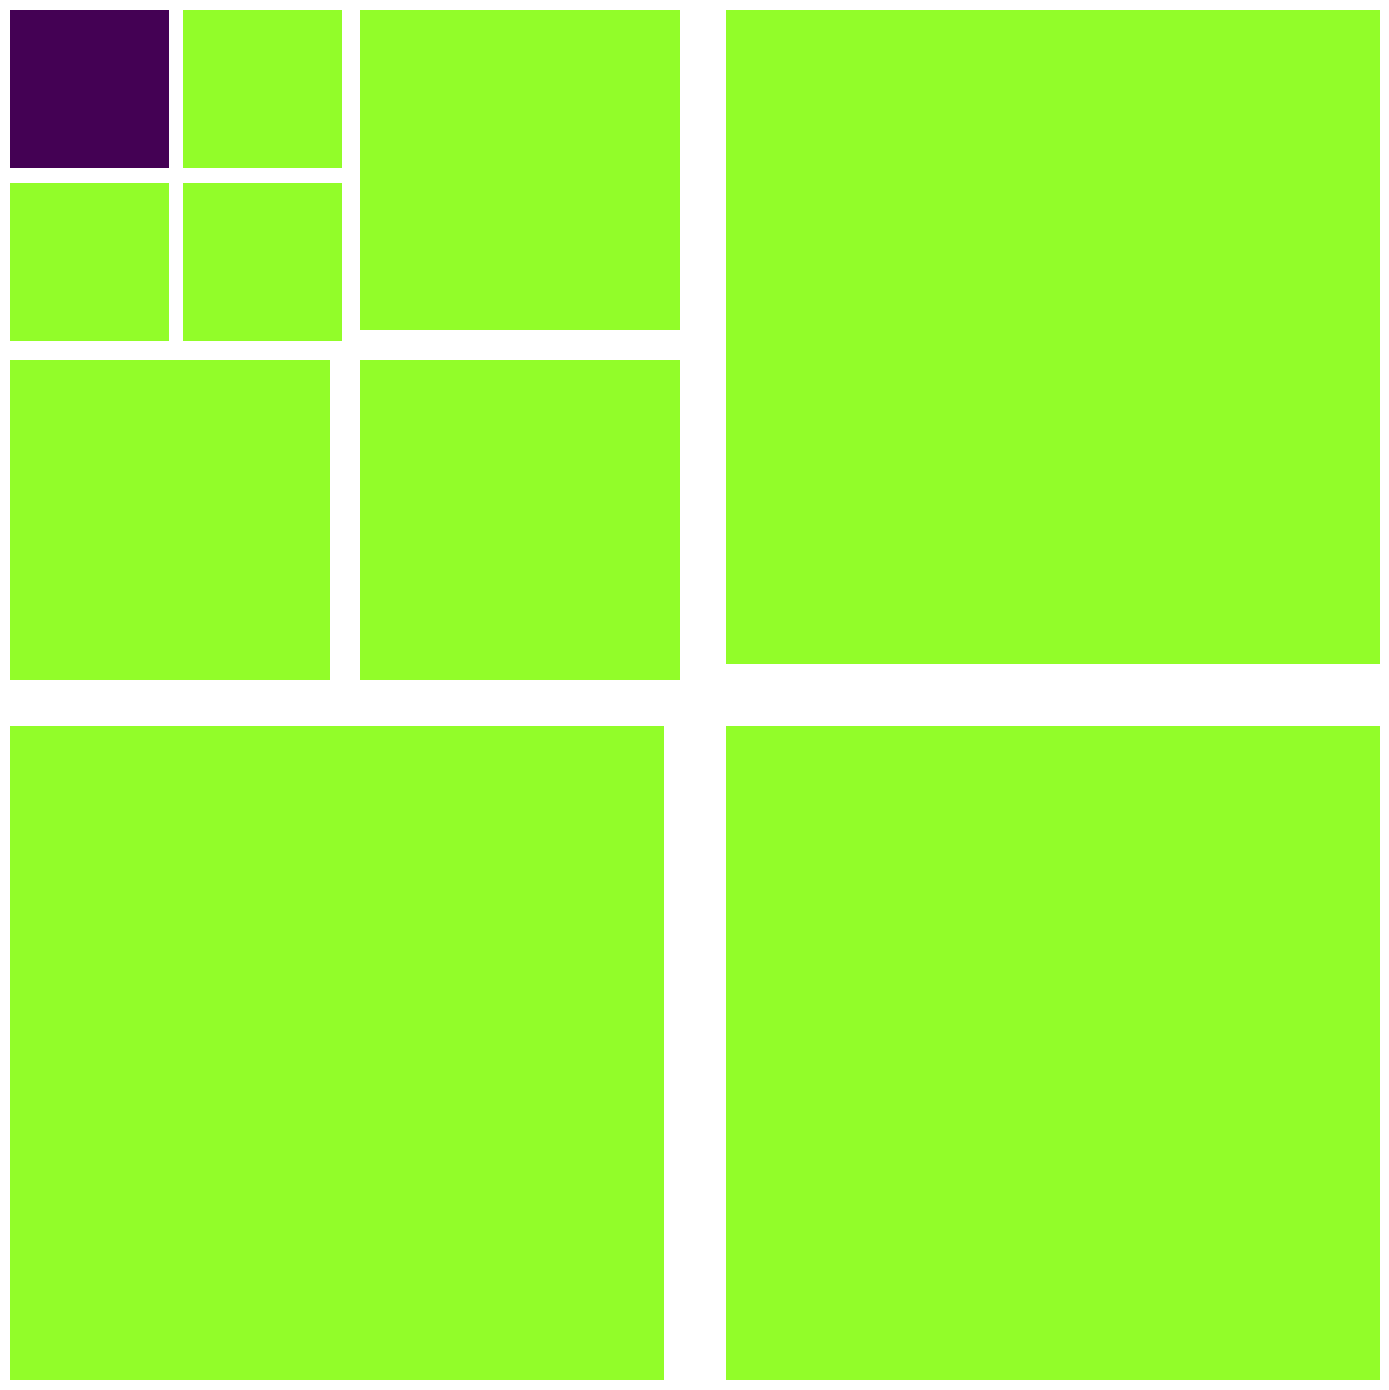

In [65]:
wl = dorito.wavelets.Wavelets(np.ones((2000, 2000)), level=3)


tree_plot(wl.coeffs, wl.level)